In [229]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder
)
import os
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [230]:
os.listdir('archive')

['ev_qiymetleri.csv', 'heart_disease_15k.csv']

In [231]:
df = pd.read_csv('archive/heart_disease_15k.csv', keep_default_na=False)

In [232]:
df.head()

,age,gender,bmi,blood_pressure,cholesterol_level,blood_sugar,heart_rate,exercise_level,smoking_status,alcohol_intake,family_history,diabetes_status,stress_level,sleep_hours,chest_pain_type,diet_type,occupation,ecg_results,heart_disease
0,44,Male,17.2,120,Normal,86,67,None,Never,Moderate,No,No Diabetes,1,6.8,None,High Fat,Moderate Activity,Left Ventricular Hypertrophy,0
1,58,Female,22.0,156,Normal,114,87,Moderate,Never,None,No,No Diabetes,8,6.0,Atypical Angina,High Fat,Light Activity,Normal,0
2,27,Male,17.8,116,Normal,99,81,Low,Never,Heavy,No,No Diabetes,6,6.2,Non-anginal Pain,High Protein,Sedentary,Normal,1
3,70,Male,24.8,153,Normal,121,84,None,Never,Moderate,Yes,No Diabetes,2,6.7,Atypical Angina,Mediterranean,Sedentary,ST-T Abnormality,1
4,62,Male,20.5,148,Normal,119,78,Moderate,Never,None,No,No Diabetes,1,6.2,Atypical Angina,Balanced,Sedentary,Normal,1


In [233]:
df.shape

(15000, 19)

In [234]:
df.isnull().sum()

age                  0
gender               0
bmi                  0
blood_pressure       0
cholesterol_level    0
blood_sugar          0
heart_rate           0
exercise_level       0
smoking_status       0
alcohol_intake       0
family_history       0
diabetes_status      0
stress_level         0
sleep_hours          0
chest_pain_type      0
diet_type            0
occupation           0
ecg_results          0
heart_disease        0
dtype: int64

In [235]:
df.duplicated().sum()

np.int64(0)

In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                15000 non-null  int64  
 1   gender             15000 non-null  object 
 2   bmi                15000 non-null  float64
 3   blood_pressure     15000 non-null  int64  
 4   cholesterol_level  15000 non-null  object 
 5   blood_sugar        15000 non-null  int64  
 6   heart_rate         15000 non-null  int64  
 7   exercise_level     15000 non-null  object 
 8   smoking_status     15000 non-null  object 
 9   alcohol_intake     15000 non-null  object 
 10  family_history     15000 non-null  object 
 11  diabetes_status    15000 non-null  object 
 12  stress_level       15000 non-null  int64  
 13  sleep_hours        15000 non-null  float64
 14  chest_pain_type    15000 non-null  object 
 15  diet_type          15000 non-null  object 
 16  occupation         150

In [237]:
df.describe()

,age,bmi,blood_pressure,blood_sugar,heart_rate,stress_level,sleep_hours,heart_disease
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,49.541467,26.989873,142.620867,124.926000,76.203067,5.505467,7.002360,0.685800
std,12.750762,4.953800,13.215212,12.991866,6.332454,2.870863,1.192581,0.464212
min,20.000000,16.000000,90.000000,76.000000,53.000000,1.000000,3.000000,0.000000
25%,41.000000,23.500000,134.000000,116.000000,72.000000,3.000000,6.200000,0.000000
50%,50.000000,27.000000,143.000000,125.000000,76.000000,6.000000,7.000000,1.000000
75%,58.000000,30.400000,152.000000,134.000000,80.000000,8.000000,7.800000,1.000000
max,80.000000,45.000000,190.000000,174.000000,101.000000,10.000000,10.000000,1.000000


In [238]:
df.describe(include='object')

,gender,cholesterol_level,exercise_level,smoking_status,alcohol_intake,family_history,diabetes_status,chest_pain_type,diet_type,occupation,ecg_results
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,2,3,5,3,4,2,4,5,5,4,3
top,Male,Normal,Low,Never,Low,No,No Diabetes,None,Balanced,Sedentary,Normal
freq,8231,11314,5276,6670,5391,10561,10525,5250,4429,5903,8232


In [239]:
df.dtypes.to_frame(name='dtypes')

,dtypes
age,int64
gender,object
bmi,float64
blood_pressure,int64
cholesterol_level,object
blood_sugar,int64
heart_rate,int64
exercise_level,object
smoking_status,object
alcohol_intake,object


In [240]:
df['heart_disease'].value_counts()

heart_disease
1    10287
0     4713
Name: count, dtype: int64

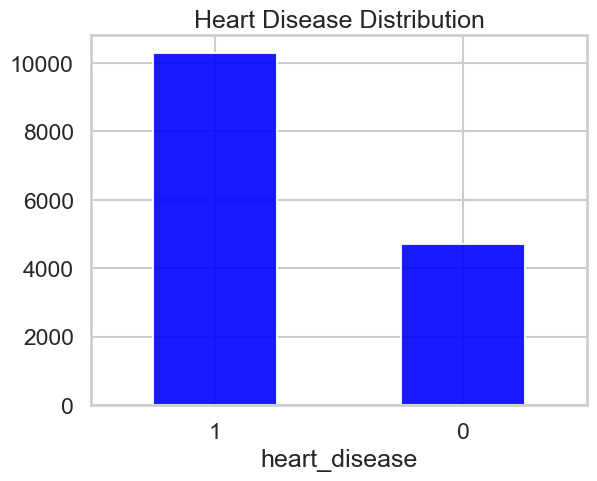

In [241]:
df['heart_disease'].value_counts().plot(kind='bar' , alpha=0.9 ,color='blue')
sns.set_style('whitegrid')
sns.set_context('talk')
plt.Figure(figsize=(10,8))
plt.xticks(rotation=0 , ha='center')
plt.grid(visible=True)
plt.title('Heart Disease Distribution')
plt.show()

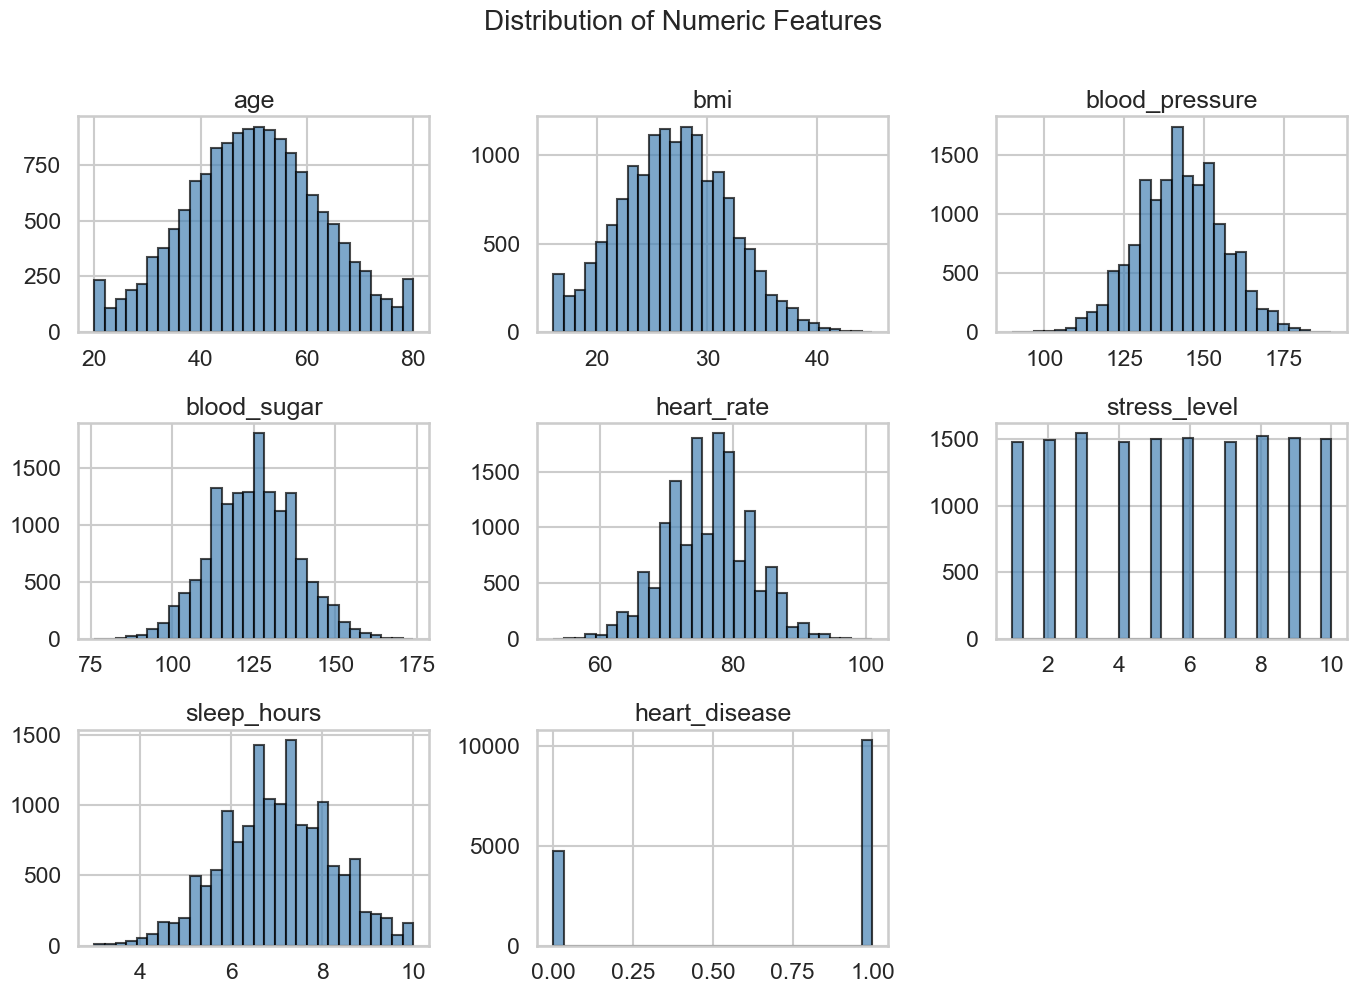

In [242]:
df.select_dtypes(include='number').hist(figsize=(14,10), bins=30,color='steelblue',edgecolor='black', alpha=0.7)
plt.suptitle('Distribution of Numeric Features', fontsize=20 ,y=1)
plt.tight_layout()
plt.show()

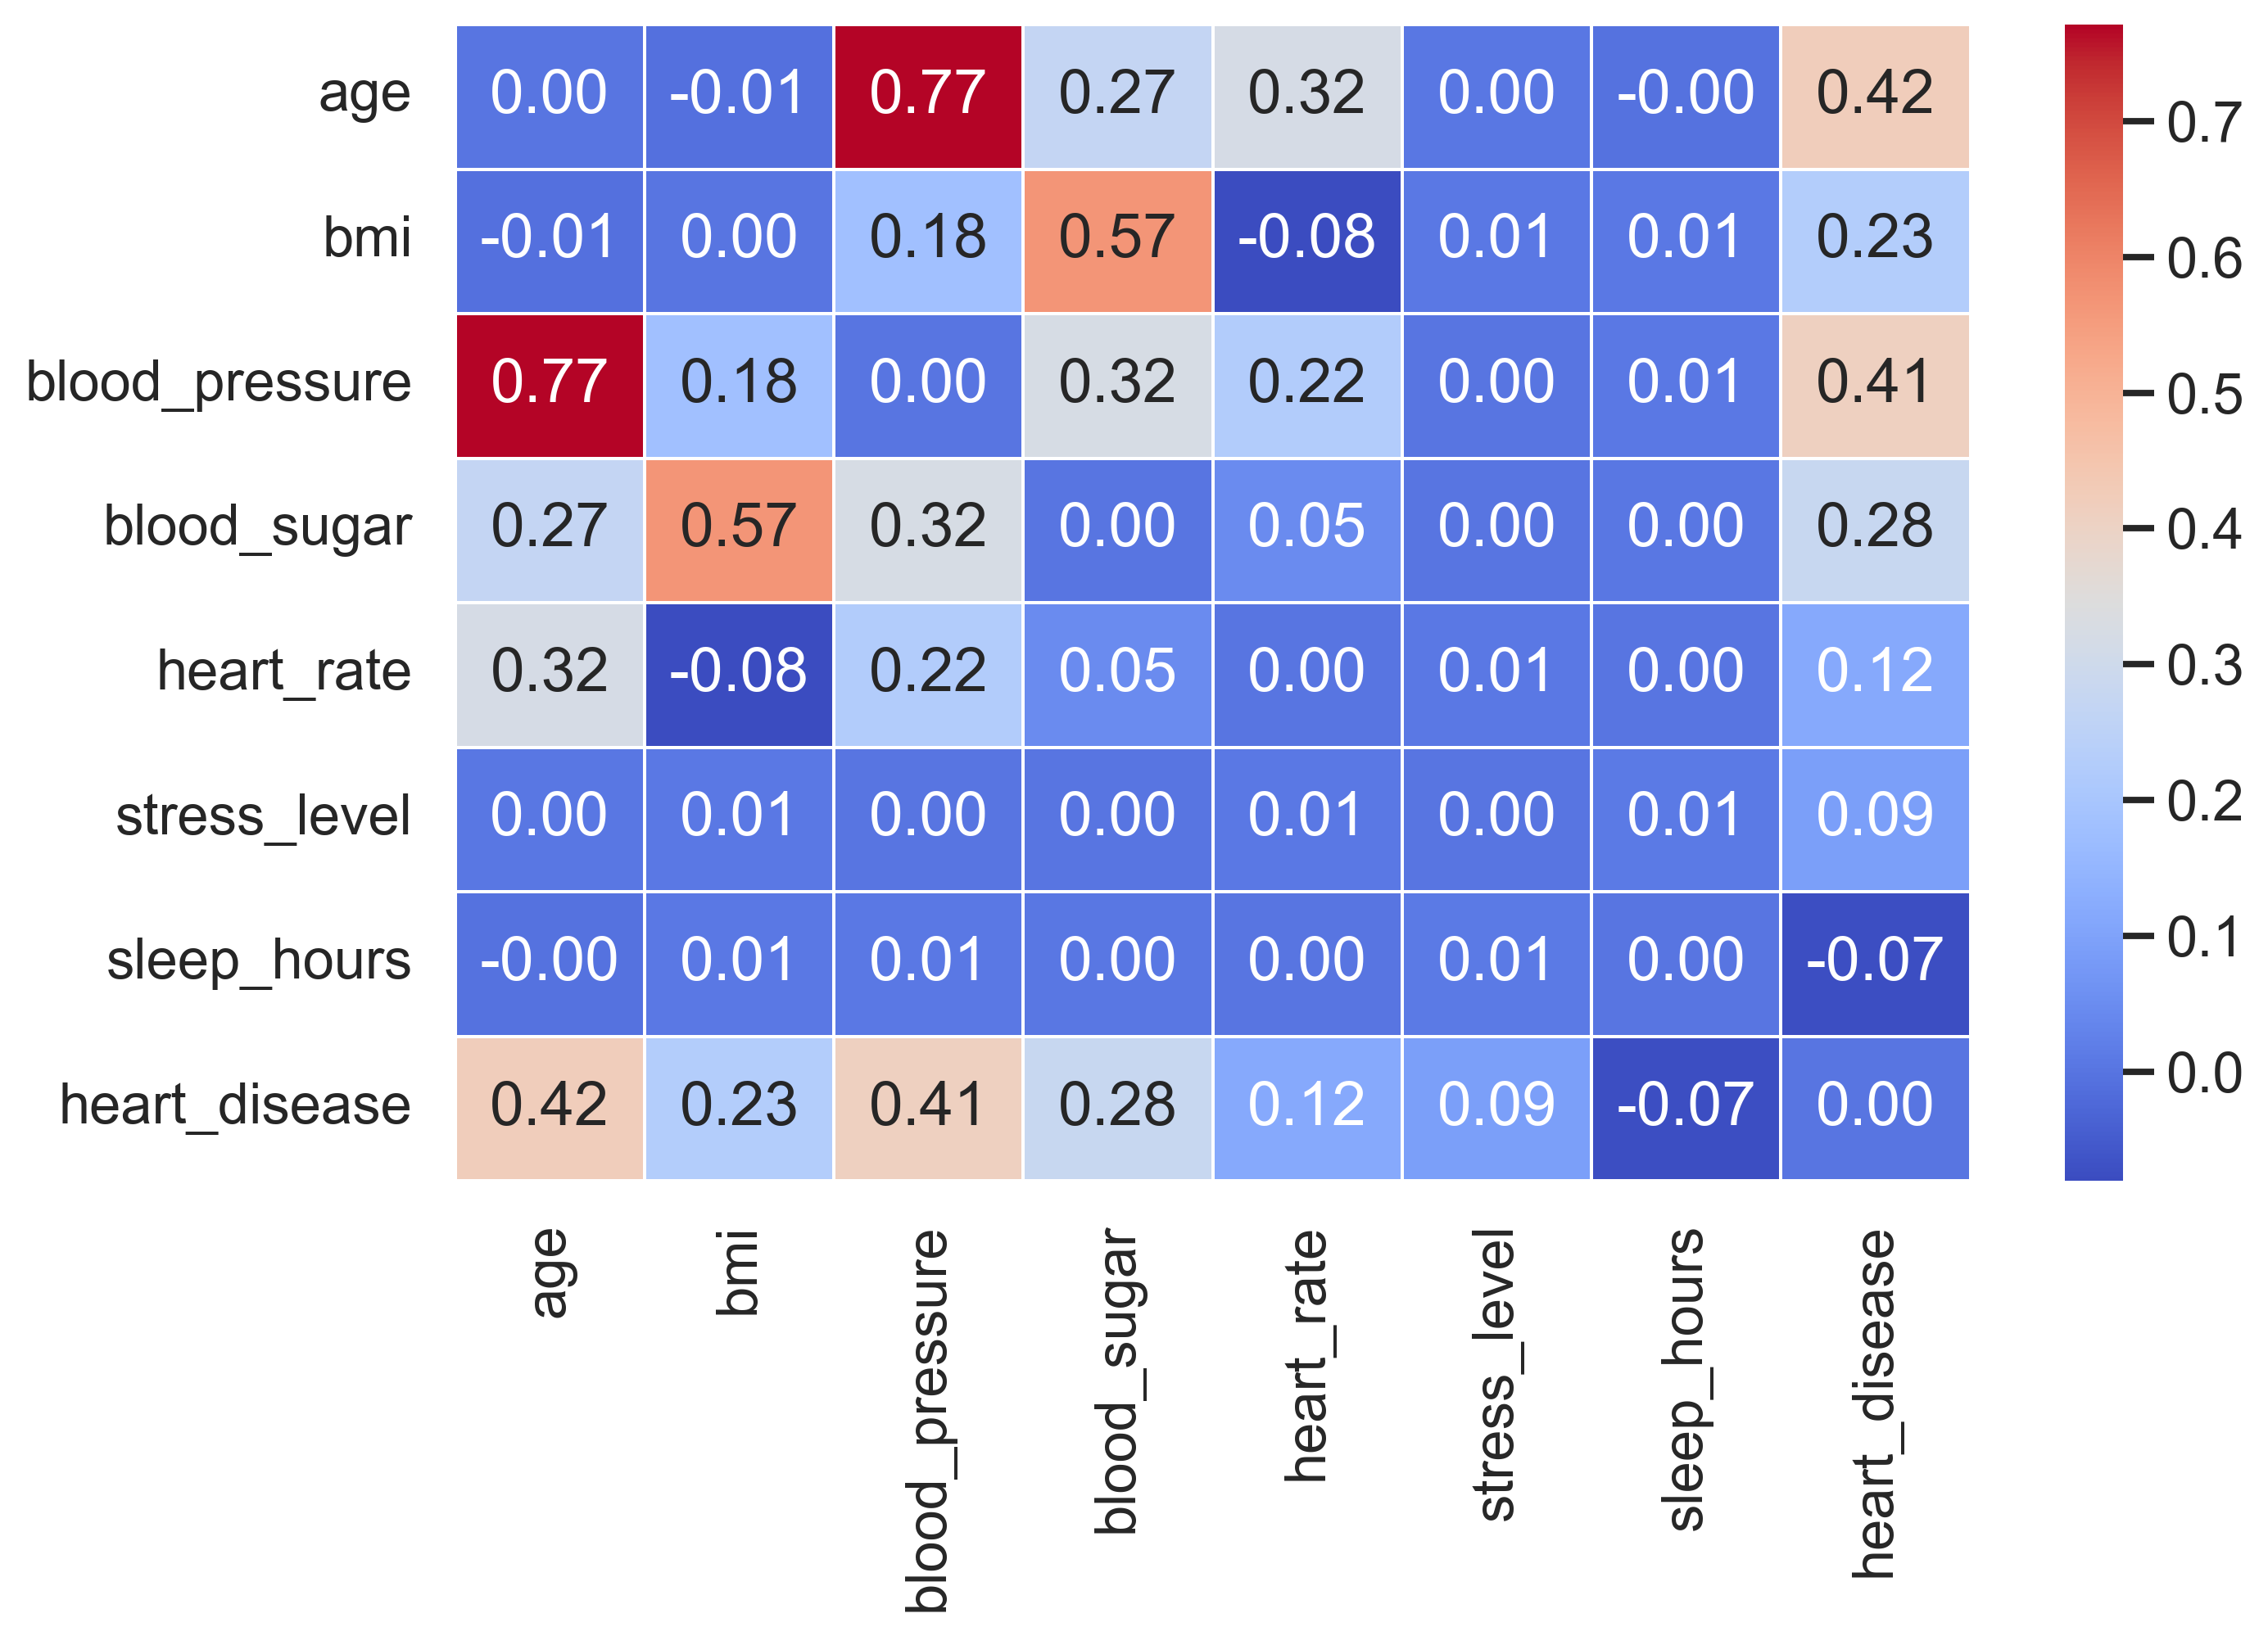

In [243]:
corr = df.select_dtypes(include='number').corr()
np.fill_diagonal(corr.values , 0)

plt.figure(figsize=(10,7) ,dpi=300)
sns.heatmap(corr , annot=True , fmt='.2f' , cmap='coolwarm', linewidths=0.5)
plt.tight_layout()
plt.show()

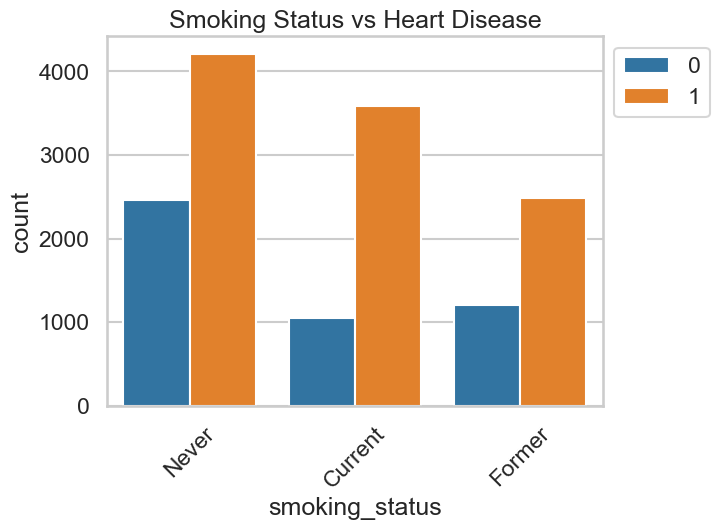

In [244]:
sns.countplot(data=df, x='smoking_status', hue='heart_disease')
plt.xticks(rotation=45)
plt.title('Smoking Status vs Heart Disease')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

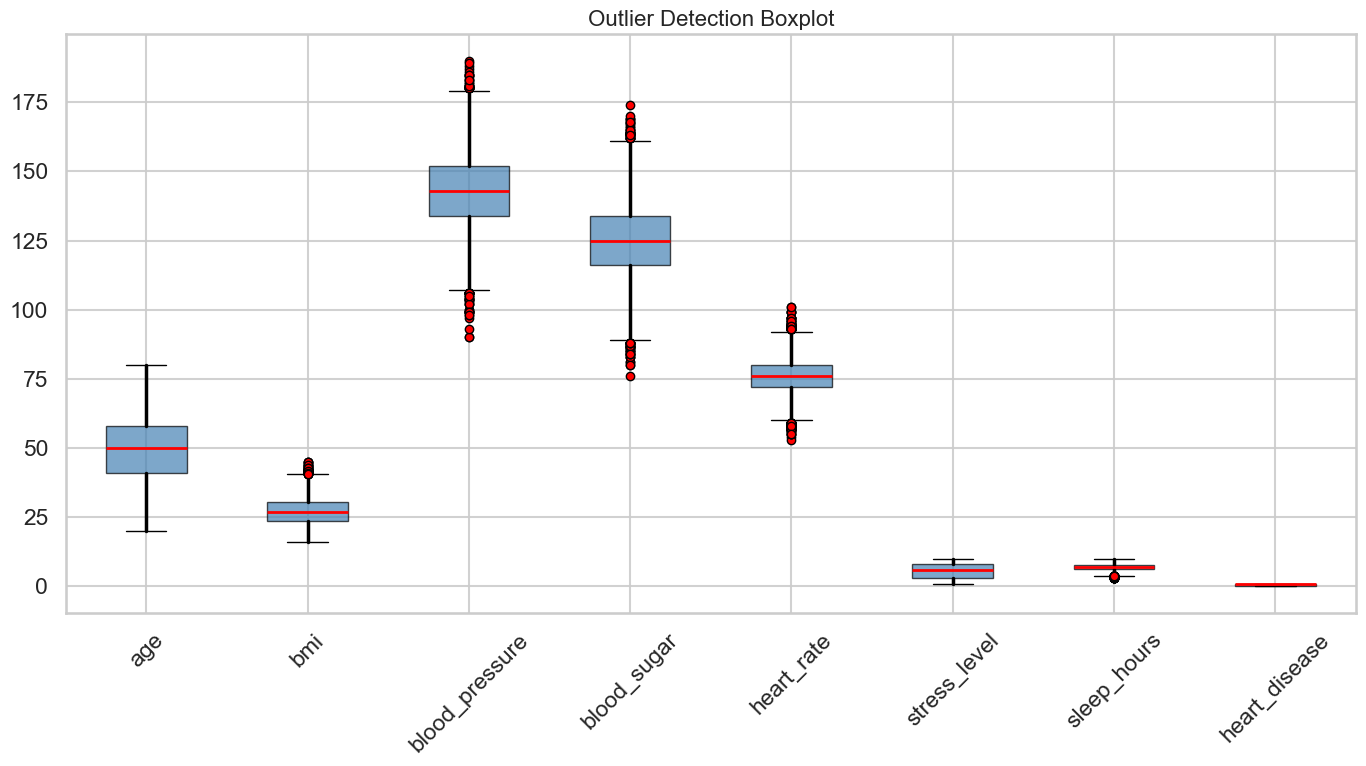

In [245]:
df.select_dtypes(include='number').boxplot(
    figsize=(14, 8),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6)
)
plt.xticks(rotation=45 , ha='center')
plt.title('Outlier Detection Boxplot', fontsize=16)
plt.grid(True , alpha=0.9)
plt.tight_layout()
plt.show()

In [246]:
df

,age,gender,bmi,blood_pressure,cholesterol_level,blood_sugar,heart_rate,exercise_level,smoking_status,alcohol_intake,family_history,diabetes_status,stress_level,sleep_hours,chest_pain_type,diet_type,occupation,ecg_results,heart_disease
0,44,Male,17.2,120,Normal,86,67,None,Never,Moderate,No,No Diabetes,1,6.8,None,High Fat,Moderate Activity,Left Ventricular Hypertrophy,0
1,58,Female,22.0,156,Normal,114,87,Moderate,Never,None,No,No Diabetes,8,6.0,Atypical Angina,High Fat,Light Activity,Normal,0
2,27,Male,17.8,116,Normal,99,81,Low,Never,Heavy,No,No Diabetes,6,6.2,Non-anginal Pain,High Protein,Sedentary,Normal,1
3,70,Male,24.8,153,Normal,121,84,None,Never,Moderate,Yes,No Diabetes,2,6.7,Atypical Angina,Mediterranean,Sedentary,ST-T Abnormality,1
4,62,Male,20.5,148,Normal,119,78,Moderate,Never,None,No,No Diabetes,1,6.2,Atypical Angina,Balanced,Sedentary,Normal,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,49,Female,21.3,136,Normal,106,75,High,Current,Moderate,No,Type 2,6,6.5,Asymptomatic,High Fat,Heavy Activity,Normal,1
14996,52,Female,21.4,141,Normal,120,86,None,Current,Low,No,No Diabetes,8,6.1,Typical Angina,Vegetarian,Moderate Activity,Normal,0
14997,40,Male,26.3,126,Normal,118,86,Moderate,Current,None,Yes,No Diabetes,10,6.9,Non-anginal Pain,High Protein,Light Activity,Normal,1
14998,52,Male,21.3,138,Normal,134,74,None,Former,Low,No,No Diabetes,5,6.4,None,High Fat,Sedentary,ST-T Abnormality,0


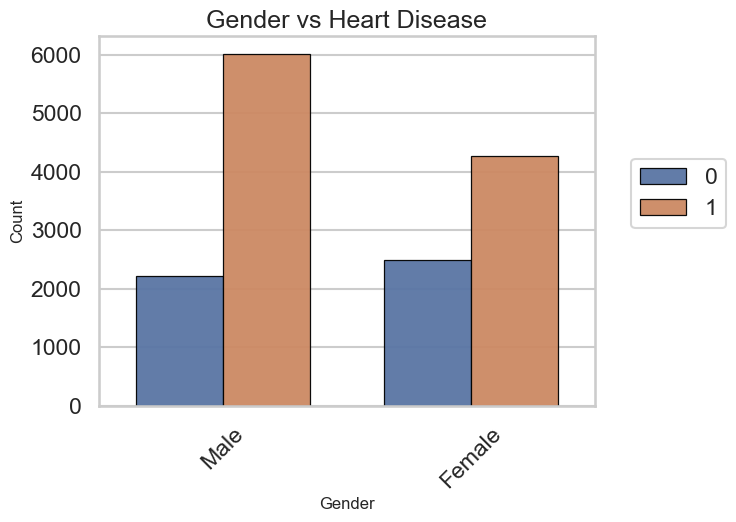

In [247]:
sns.countplot(data=df, x='gender', hue='heart_disease', palette='deep', edgecolor='black', linewidth=0.9, alpha=0.95, width=0.7)
plt.xticks(rotation=45)
plt.title('Gender vs Heart Disease')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 0.7), loc='upper left')
plt.show()

# remainder  yoxdur çünki biz artıq bütün sütunları bölüşdürmüşük dəyişkənlərə vermişik

# əgərki dəyişkənlərə verməsəydik remainder='passthrough' isdifadə edərdik

# burda biz robustscaler isdifadə etməkdə məqsəd outlier çox idi boxplot ilə baxdıq

# biz IQR ilə outlier olan sətirləri silə bilərdik amma mən datada məlumat itirmək isdəmirəm diyə RobustScaler isdifadə ettim silinmədi data və outlierlərin təsirini azaldır

# Biz özümüz sıra veririk ki, Normal < Borderline High < High < Very High düzgün olsun Əlifba sırasında "Normal" 2-dir, "Borderline High" 0-dır — yəni model düşünür Normal > Borderline High. Bu yanlışdır.

In [248]:
cat_cols = ['gender', 'family_history', 'smoking_status', 'diabetes_status', 
            'chest_pain_type', 'diet_type', 'occupation', 'ecg_results']
num_clean = ['age', 'stress_level']
num_outlier = ['blood_pressure', 'blood_sugar', 'bmi', 'heart_rate' , 'sleep_hours']
ord_cols = ['cholesterol_level', 'exercise_level', 'alcohol_intake']
ord_categories = [
    ['Normal', 'Borderline High', 'High', 'Very High'],
    ['None', 'Low', 'Moderate', 'High', 'Very High'],
    ['None', 'Low', 'Moderate', 'Heavy']
]

preprocessor = ColumnTransformer([
    ('ord', OrdinalEncoder(categories=ord_categories), ord_cols),
    ('robust' , RobustScaler() ,num_outlier),
    ('col' , OneHotEncoder(drop='first') , cat_cols),
    ('num' , StandardScaler() ,num_clean)
    ],
    n_jobs=-1
)

# stratify=y  Əgər yazmasaydıq bəzən bir kateqoriya testə heç düşməyə bilər O zaman model onu test edə bilmir və nəticə yanlış olur Əgər datanda hər kateqoriya 16%-dirsə, train-də də 16%, test-də də 16% olsun. Heç bir kateqoriya çox və ya az düşməsin.

In [249]:
X = df.drop(columns='heart_disease' , axis=1)
y = df['heart_disease']

X_train , X_test , y_train , y_test = train_test_split(X , y , train_size=0.8, random_state=42 ,stratify=y) 

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (12000, 18)
Test: (3000, 18)


# brute — hər nöqtəni hamı ilə müqayisə edir. Ən yavaş amma ən dəqiq. 
# kd_tree — datanı ağac şəklində bölür, sürətli axtarır. Az sütun olanda yaxşı işləyir (8 sütun) 
# ball_tree — datanı kürə şəklində bölür, çox sütun olanda kd_tree-dən yaxşı işləyir (50+ sütun)

# np.argmax(scores) — siyahıdakı ən böyük dəyərin index-ini tapır
# k_range[np.argmax(scores)] — o index-ə uyğun K dəyərini tapır 
# max(scores) — ən yüksək accuracy-ni tapır 

# pipe.score(X_test, y_test) — test datanı verir, model proqnoz edir, accuracy qaytarır

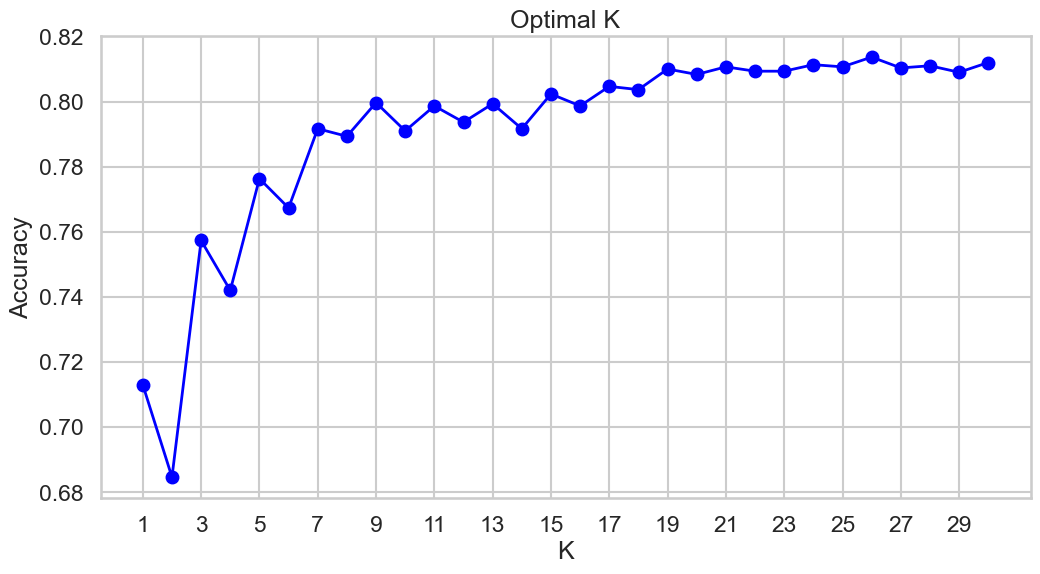

Ən yaxsi K: 26, Accuracy: 0.8137


In [250]:
k_range = range(1,31)
scores = []
for k in k_range:
    pipe = Pipeline([
        ('preprocessor' , preprocessor),
        ('model' , KNeighborsClassifier(n_neighbors=k , algorithm='kd_tree')),
    ])
    pipe.fit(X_train , y_train)
    scores.append(pipe.score(X_test , y_test))

plt.figure(figsize=(12, 6))
plt.plot(k_range, scores, 'b-o', linewidth=2)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Optimal K')
plt.xticks(range(1, 31, 2))
plt.grid(visible=True , axis='both')
plt.show()

best_k = k_range[np.argmax(scores)]
print(f"Ən yaxsi K: {best_k}, Accuracy: {max(scores):.4f}")

# average='macro' — hər sinifə bərabər baxır 
# average='weighted' — çox olan sinif daha çox təsir edir 
# average='binary' — yalnız 2 sinif olanda, sinif 1-in metrikasını qaytarır
# average='micro' — bütün TP, FP-ləri birləşdirib hesablayır

In [251]:
models = {
    'Euclidean+Uniform' : KNeighborsClassifier(n_neighbors=best_k , metric='euclidean' , weights='uniform'),
    'Euclidean+Distance' : KNeighborsClassifier(n_neighbors=best_k , metric='euclidean' , weights='distance'),
    'Manhattan+Uniform': KNeighborsClassifier(n_neighbors=best_k , metric='manhattan' , weights='uniform'),
    'Manhattan+Distance': KNeighborsClassifier(n_neighbors=best_k , metric='manhattan' , weights='distance'),
}

results = []
for name , model  in models.items():
    pipe = Pipeline([
        ('preprocessor' , preprocessor),
        ('model' , model)
    ])
    pipe.fit(X_train , y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        'Model':name,
        'Accuracy':accuracy_score(y_test ,y_pred),
        'Precision' : precision_score(y_test ,y_pred , average='macro'),
        'Recall' : recall_score(y_test , y_pred , average='macro'),
        'f1 score': f1_score(y_test , y_pred , average='macro')
    })
pd.DataFrame(results).set_index('Model')

,Accuracy,Precision,Recall,f1 score
Model,,,,
Euclidean+Uniform,0.813667,0.786725,0.771660,0.778245
Euclidean+Distance,0.809000,0.783732,0.759068,0.768952
Manhattan+Uniform,0.821333,0.797622,0.776964,0.785652
Manhattan+Distance,0.818667,0.797838,0.766979,0.778922


# addımadı__parametr

In [252]:
pipe_grid = Pipeline([
    ('preprocessor' , preprocessor),
    ('model' , KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': range(1,31),
    'model__metric': ['euclidean' , 'manhattan'],
    'model__weights': ['uniform' , 'distance']
}

grid = GridSearchCV(pipe_grid , param_grid , scoring='f1' , cv=5 , n_jobs=-1)
grid.fit(X_train ,y_train)

print(f"Ən yaxsi parametrlər: {grid.best_params_}")
print(f"Ən yaxsi F1: {grid.best_score_:.4f}")
print(f"Test Accuracy: {grid.score(X_test, y_test):.4f}")

y_pred_final = grid.predict(X_test)
print(classification_report(y_test, y_pred_final))

Ən yaxsi parametrlər: {'model__metric': 'manhattan', 'model__n_neighbors': 29, 'model__weights': 'uniform'}
Ən yaxsi F1: 0.8757
Test Accuracy: 0.8754
              precision    recall  f1-score   support

           0       0.76      0.63      0.69       943
           1       0.84      0.91      0.88      2057

    accuracy                           0.82      3000
   macro avg       0.80      0.77      0.78      3000
weighted avg       0.82      0.82      0.82      3000



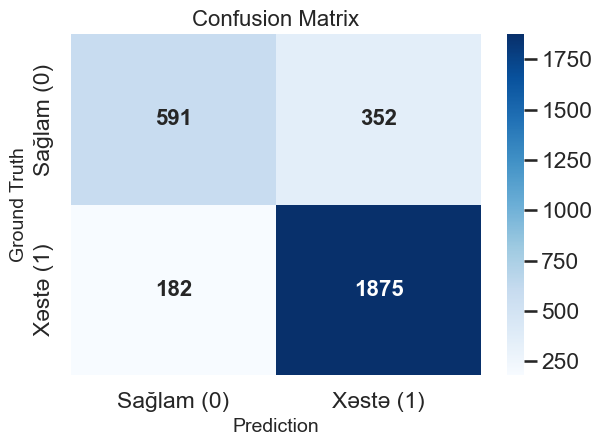

TN (Doğru Sağlam): 591
FP (Yanlış Xəstə): 352
FN (Yanlış Sağlam): 182
TP (Doğru Xəstə): 1875


In [253]:
cm = confusion_matrix(y_test , y_pred_final)

sns.heatmap(cm , annot=True , fmt='d' , cmap='Blues' ,
            xticklabels=['Sağlam (0)', 'Xəstə (1)'],
            yticklabels=['Sağlam (0)', 'Xəstə (1)'],
            annot_kws={'size': 16, 'weight': 'bold'})
plt.xlabel('Prediction', fontsize=14)
plt.ylabel('Ground Truth', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

TN , FP , FN , TP = cm.ravel()
print(f"TN (Doğru Sağlam): {TN}")
print(f"FP (Yanlış Xəstə): {FP}")
print(f"FN (Yanlış Sağlam): {FN}")
print(f"TP (Doğru Xəstə): {TP}")

# grid.best_estimator_  GridSearchCV-nin tapdığı ən yaxşı model. 120 kombinasiyadan ən yüksək F1 verən.

In [254]:
cv_scores = cross_val_score(grid.best_estimator_ , X_train , y_train , cv=5 , scoring='f1')
print(f'CV F1 Scores: {cv_scores}')
# cv_scores = [0.78, 0.76, 0.79, 0.77, 0.78]
print(f"Mean: {cv_scores.mean():.4f} ,  {cv_scores.std():.4f}")

CV F1 Scores: [0.87612941 0.87852619 0.88099365 0.87281214 0.87012231]
Mean: 0.8757 ,  0.0039


In [255]:
print(f"Train Accuracy: {grid.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {grid.score(X_test, y_test):.4f}")

Train Accuracy: 0.8842
Test Accuracy: 0.8754


In [256]:
new_patient = pd.DataFrame([{
    'age': 55,
    'gender': 'Male',
    'bmi': 32.5,
    'blood_pressure': 165,
    'cholesterol_level': 'High',
    'blood_sugar': 140,
    'heart_rate': 85,
    'exercise_level': 'None',
    'smoking_status': 'Current',
    'alcohol_intake': 'Heavy',
    'family_history': 'Yes',
    'diabetes_status': 'Type 2',
    'stress_level': 8,
    'sleep_hours': 4.5,
    'chest_pain_type': 'Typical Angina',
    'diet_type': 'High Fat',
    'occupation': 'Sedentary',
    'ecg_results': 'ST-T Abnormality'
}])

print(f"Prediction: {'Heart Disease' if grid.predict(new_patient)[0] == 1 else 'Healthy'}")
print(f"Probability: {grid.predict_proba(new_patient)[0][1]*100:.1f}%")

Prediction: Heart Disease
Probability: 100.0%
